In [1]:
import numpy as np
import sys, os

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.microscopy_image as mi
import constants as constants

In [2]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Jelle"
SAMPLE_ID = "MSI_XENIUM"
MODALITY_NAME = "xenium"

In [ ]:
mi.preprocess_microscopy_image(
    path=PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    crop = True,
    filter_strength = constants.ImagingFilterStrength.AGGRESSIVE,
    smoothing = True,
    color_enhancement = True,
    debug_mode = True
)

In [ ]:
from skimage import io
msi_image = io.imread("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/alignment/msi/resulting_image.tiff")
xenium_image = io.imread("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/xenium/clipped.tif")

In [38]:
ORIGIN_OFFSET = (834, 557)
ORIGINAL_MSI_SIZE = (751, 345)
ORIGINAL_XENIUM_SIZE = (112568, 54833)
SMALL_XENIUM_SIZE = (28142, 13708)

In [21]:
print("MSI Aligned Image: ", msi_image.shape)
print("Xenium Image: ", xenium_image.shape)

MSI Aligned Image:  (28142, 13708, 3)
Xenium Image:  (28142, 13708)


In [30]:
offset = None
indices = np.argwhere(msi_image[:, :, 0] != -1.0)
if indices.size == 0:
    offset = None  # or raise an exception if preferred
offset =  tuple(indices[0])
print("Offset: ", offset)

Offset:  (np.int64(557), np.int64(834))


In [4]:
msi_image = np.where(msi_image >= 0, msi_image, 0.0)

# Normalize the Xenium image to the range [0, 1]
xenium_image = xenium_image.astype(np.float32)
xenium_image = (xenium_image - np.min(xenium_image)) / (np.max(xenium_image) - np.min(xenium_image))

final_image = np.zeros_like(msi_image)
final_image[:, :, 0] = msi_image[:, :, 0]
final_image[:, :, 1] = xenium_image

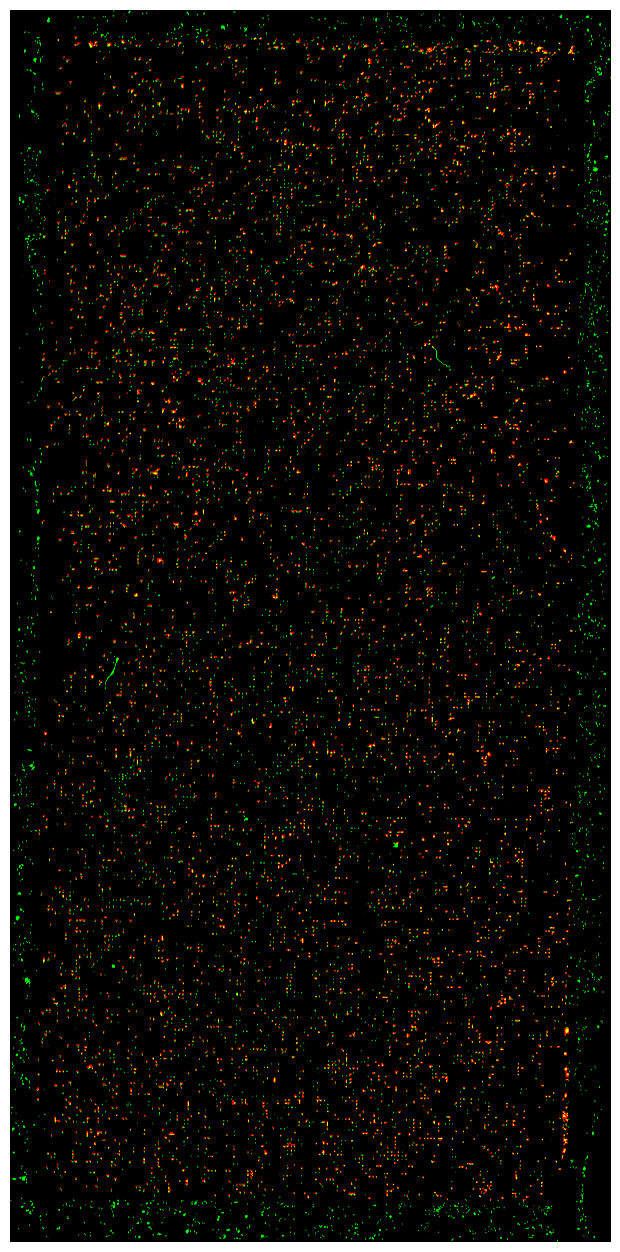

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
plt.axis("off")
plt.imshow(final_image)

In [ ]:
io.imsave("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/alignment/msi_xenium_combined.tiff", final_image)

In [7]:
import tifffile as tiff

original_msi_size, original_xenium_size, small_xenium_size = None, None, None

In [8]:
with tiff.TiffFile("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/morphology_focus_0000.ome.tif") as tif:
    original_xenium_size = tif.pages[0].shape 

In [10]:
with tiff.TiffFile("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/msi/coordinates_MALDI_MSI_spots.tif") as tif:
    original_msi_size = tif.pages[0].shape 

In [11]:
with tiff.TiffFile("/mnt/data/lorenzo/VSC_DATA/Jelle/MSI_XENIUM/xenium/clipped.tif") as tif:
    small_xenium_size = tif.pages[0].shape 

In [15]:
print("Original MSI Size: ", original_msi_size)
print("Original Xenium Size: ", original_xenium_size)
print("Small Xenium Size: ", small_xenium_size)

origin_offset = (750.7061746768271, 662.3967002942585)

Original MSI Size:  (751, 345)
Original Xenium Size:  (112568, 54833)
Small Xenium Size:  (28142, 13708)


In [55]:
ORIGIN_OFFSET = (834, 557)
ORIGINAL_MSI_SIZE = (751, 345)
ORIGINAL_XENIUM_SIZE = (112568, 54833)
SMALL_XENIUM_SIZE = (28142, 13708)

def translate_coord(coordinates: tuple[float, float], source_size: tuple[int, int], destination_size: tuple[int, int]) -> tuple[float, float]:
    """
    Map a pixel coordinate from one image to another with a different size.

    Parameters:
    -----------
    coord : tuple[float, float]
        The coordinate (x, y) in the source image.
    size_from : tuple[int, int]
        The size (W, H) of the source image.
    size_to : tuple[int, int]
        The size (W, H) of the target image.

    Returns:
    --------
    tuple[float, float]
        The mapped coordinate (x', y') in the target image.
    """
    x, y = coordinates
    w_from, h_from = source_size
    w_to, h_to = destination_size

    x_norm = x / w_from
    y_norm = y / h_from

    x_new = x_norm * w_to
    y_new = y_norm * h_to

    return (x_new, y_new)

def map_xenium_to_msi(xenium_coord: tuple[int, int], original_xenium_size: tuple[int, int], small_xenium_size: tuple[int, int], original_msi_size: tuple[int, int], origin_offset: tuple[int, int], flip_y: bool = True):
    """
    Map a Xenium coordinate from the original image to the corresponding MSI coordinate.

    Parameters:
    -----------
    xenium_coord : tuple[int, int]
        Coordinate in the Xenium image.
    original_xenium_size : tuple[int, int]
        Size of the original Xenium image (width, height).
    small_xenium_size : tuple[int, int]
        Size of the small Xenium image (width, height).
    original_msi_size : tuple[int, int]
        Size of the original MSI image (width, height).
    origin_offset : tuple[int, int] 
        Offset to adjust the origin of the Xenium coordinate.
    flip_y : bool, optional
        Whether to flip the y-coordinate (default is True).

    Returns:
    --------
    tuple[float, float] or (None, None)
        Mapped MSI coordinate (x', y') as float, or (None, None)
        if the coordinate is out of bounds.
    """

    # Map from small Xenium to original Xenium
    xenium_coord_small = translate_coord(xenium_coord, original_xenium_size, small_xenium_size)

    # Adjust for origin offset
    xenium_coord_small = (xenium_coord_small[0] - origin_offset[0], xenium_coord_small[1] - origin_offset[1])
    
    # Map from original Xenium to MSI
    msi_coord = translate_coord(xenium_coord_small, small_xenium_size, original_msi_size)

    # Flip the y-coordinate if required
    if flip_y:
        msi_coord = (msi_coord[0], original_msi_size[1] - msi_coord[1])

    # Ensure the coordinate is within bounds
    if msi_coord[0] < 0 or msi_coord[0] >= original_msi_size[0] or msi_coord[1] < 0 or msi_coord[1] >= original_msi_size[1]:
        return(None, None)
    
    return msi_coord

In [41]:
big_origin_offset = translate_coord(ORIGIN_OFFSET, SMALL_XENIUM_SIZE, ORIGINAL_XENIUM_SIZE)
print("Big Origin Offset: ", big_origin_offset)

Big Origin Offset:  (3336.0, 2228.0406332068865)


In [53]:
result = map_xenium_to_msi(big_origin_offset, ORIGINAL_XENIUM_SIZE, SMALL_XENIUM_SIZE, ORIGINAL_MSI_SIZE, ORIGIN_OFFSET, flip_y=False)
print("Mapped MSI Coordinate for (0, 0): ", result)

Mapped MSI Coordinate for (0, 0):  (0.0, 0.0)
